In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output # To clear the console at each iteration 
from scipy.io import wavfile
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d, splrep, splev 

# Contextualização do problema


## 1 - Descrição das físicas envolvidas (PDEs)


Considere o alto-falante da figura a seguir: O dispositivo é composto por imã permanente (1), uma bobina de cobre com $N$ espiras (2), um sistema elástico de fixação (3) e um cone rígido (4). Uma versão detalhada dos demais componentes é apresentada na fig. 2. 

<center>Fig. 1 Geometria de um alto-falante.</center>

<a title="Svjo, CC BY-SA 3.0 &lt;https://creativecommons.org/licenses/by-sa/3.0&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Loudspeaker-bass.png"><img width="256" alt="Loudspeaker-bass" src="../Figs/Loudspeaker-bass.png"></a>

<center>Fig. 2 Componentes de um alto-falante. <a href="http://www.novacon.com.br/audioafca.htm"> Fonte: Novacon</a>. </center>
<p>
    <img width="450" height="85" src="../Figs/Aula04_alto-falante_partes.jpg">
</p>


No que se refere às físicas envolvidas, podemos destacar o circuito magnético governado pelas equações de Maxwell, o problema de tensão e deformação das partes móveis do alto-falante, regido pela mecânica dos sólidos e o problema de propagação da onda acústica gerada pelo movimento do cone (equação de onda). Alguns exemplos das físicas envolvidas são apresentadas a seguir:

### 1.1 - O problema elastodinâmico do cone

A equação da elastodinâmica combina o equilíbrio do momento linear:

\begin{equation}
\nabla\cdot\sigma + \rho f = \rho\ddot{u}
\end{equation}

onde $u$ é o campo vetorial de deslocamento, $\ddot{u}$ é a aceleração, $\rho$ é a densidade do material, $f$ é uma força de corpo aplicada, e $\sigma$ é o tensor de tensões que está relacionado ao deslocamento por meio de uma equação constitutiva. No caso da elasticidade linear isotrópica, tem-se:

\begin{equation}
\sigma = \lambda tr(\epsilon)I + 2\mu\epsilon  
\end{equation} 
onde 
\begin{equation}
\epsilon = \frac{\nabla u + (\nabla u)^T }{2}, 
\end{equation}
é o tensor de deformação linear, I é um tensor identidade de rank dois e $\lambda$, $\mu$ são os coeficientes de Lamé. 

### 1.2 - O problema eletromagnético

Já a interação entre a corrente na bobina móvel, o imã e as peças ferromagnéticas do alto-falante é governada pelas equações de Maxwell no regime quase-estático: 

\begin{align}
\nabla\times H &=& J \\
\nabla\cdot B &=& 0 \\
\nabla\times E &=& -\frac{\partial B}{\partial t} \\
\nabla\cdot E &=& 0
\end{align}
onde $H$ é o campo magnético, $B$ a densidade de fluxo magnético, $E$ é o campo elétrico e $J$ a densidade de corrente elétrica que pode ser dividida entre a parcela injetada na bobina $J_i$ (fonte externa) e as correntes induzidas nos materiais com condutividade ($J = J_i + \sigma E$), sendo que para o caso do alto-falante o segunto termpo pode ser negligenciado. 

A solução desse sistema de equações deve levar em conta ainda a não linearidade da permeabilidade magnética $\mu$ do imã e do material ferromagnético na relação constitutiva $B = \mu(H)H$. 

### 1.3 - Acoplamento entre as duas físicas:

O acoplamento entre as duas físicas se dá pela força de Laplace:
\begin{equation}
f = J\times B
\end{equation}
onde a força de corpo do primeiro problema é gerada a partir da interação entre a corrente na bobina e o campo magnético gerado pelo ímã. Assumindo que a solução do problema eletromagnético depende da posição e velocidade da bobina, um simples alto-falante pode se tornar um problema multifísico complexo que requer a solução simultânea de diversas equações diferenciais parciais. 

Felizmente, dada a geometria axissimétrica do dispositivo (e usando algumas simplificações) é possível obter um modelo concentrado que descreve o comportamento do alto-falante por meio de um conjunto de equações diferenciais ordinárias.

## 2 - Representação por elementos concentrados (ODE)

### 2.1 - O modelo circuital equivalente.

Do ponto de vista dos terminais de uma fonte conectada ao alto-falante, o dispositivo pode ser substituído por um modelo de circuito equivalente igual ao utilizado no problema do levitador magnético.

<p>
    <img width="350" height="100" src="../Figs/LevitadorCirc.png">
</p>

No circuito, $R$ representa a resistência do fio da bobina, e pode ser estimado pela seção transversal do fio, seu comprimento total e sua condutividade $\sigma$. Em princípio, a condutividade de um condutor é função de sua temperatura, mas para a maioria das aplicações $R$ pode ser considerado constante. 

A indutância $L$ é obtida pela relação entre o fluxo magnético concatenado na bobina e a corrente $i$. O fluxo magnético por sua vez é função da geometria do alto-falante e da permeabilidade magnética das peças ao redor do imã. Desconsiderando a não linearidade das peças magnéticas a indutância passa a ser apenas função da posição da bobina, ou seja $L=f(x)$.

A condutância $G$ representa as perdas no interior das peças magnéticas. Tais perdas podem ser oriundas de correntes parasitas (correntes de Foucault) ou também devidas à magnetização e desmagnetização do material (histerese). Tais efeitos são mais significantes à medida que a frequência de operação do circuito aumenta. Assim como no caso do levitados, esses efeitos serão ignorados (G = 0).

Por fim, a força contraeletromotriz $e$ é relacionada ao trabalho realizado sobre a bobina. Ela é obtida a partir do produto do fator de força $Bl$ e a velocidade da bobina. O fator de força, por sua vez, é obtido pela razão entre a força magnética e a corrente do circuito.

\begin{equation}
Bl = \frac{fm}{i}
\end{equation}

Assim como a indutância, a força magnética possui comportamento não linear, logo $f_m=f(x,i)$. 


#### a) Aplicando a lei de Kirchhoff das tensões

Assumindo que as perdas no núcleo não são significativas ($G=0$), a lei de Kirchhoff das tensões (LKT) do circuito é dada por:

\begin{equation}
u(t) = Ri(t) + L\frac{di(t)}{dt} + Bl\frac{dx(t)}{dt}
\end{equation}

Sendo essa a equação diferencial ordinária que governa o comportamento do circuito. É importante lembrar que $L(x)$ e $Bl(x,i)$ não são constantes e que a equação governante é não linear. Entretanto, assim como no problema do levitador, é possível linearizar a equação em relação ao ponto de equilíbrio do alto-falante. 

### 2.3 - O modelo mecânico

A equação diferencial que descreve a posição da bobina é a mesma do problema do alto-falante (segunda lei de Newton). Entretanto, para este problema, a força gravitacional $f_g$ pode ser ignorada quando comparada às demais forças atuantes. Além da força magnética atuando na bobina, neste problema temos a força restauradora $f_r$ e a força de amortecimento $f_a$. Matematicamente:

\begin{align}
f &=& m \ddot x \\
f &=& f_m + f_r + f_a 
\end{align}

A força restauradora é resultado das propriedades elásticas da aranha e do anel de suspensão. O objetivo da aranha é o de manter o alinhamento axial da bobina durante o deslocamento. Já o anel de suspensão, geralmente feito de borracha, é o responsável por fixar o cone à estrutura. Considerando apenas o moviemtno axial, a combinação destes dois efeitos pode ser modelada como uma mola cuja força se opõe ao deslocamento do sistema. Neste caso, a expressão matemática da força restauradora é dada pela lei de Hooke.

\begin{align}
f_r &=& -kx 
\end{align}

Onde $k$, dado em $(N/m)$, é a constante elástica que visa condensar em um elemento concentrado (uma mola) os efeitos elásticos previstos no modelo elastodinâmico. Nota: Não confundir a constante elástica apresentada aqui com a constante experimental $k$ usada para representar a indutância nâo linear do problema do levitador.

Assim como a mola visa representar toda a elasticidade do sistema, a inércia do sistema é representada pela massa $m$ e o alto-falante pode ser interpretado como um oscilador linear. 

A força de amortecimento representa o atrito viscoso gerado pelo movimento do cone no ar. Nesse caso, para a componente ao longo do eixo de deslocamento, a força de amortecimento $f_a$ é proporcional ao negativo da velocidade ($v = \dot x$) do cone. 

\begin{align}
f_a &=& -b\dot x 
\end{align}

Onde $b$ é a constante de amortecimento que depende das características do cone e tem unidades de quilograma por segundo ($kg/s$) no SI.

Como resultado, o modelo mecânico pode ser aproximado por sistema massa-mola-amortecido. 


### 2.4 - Equações governantes e condição inicial

O problema de valor inicial é então dado pelo sistema de equações formado pelos modelos circuital e mecânico. 
A unicidade da solução é dada por meio da corrente inicial $i(0)$, a posição $x(0)$ e velocidade inicial $v(0)$ . 

\begin{align}
\dot i &=& \frac{u}{L(x)} - \frac{R}{L(x)}i - \frac{Bl(i,x)}{L(x)}\dot x\\
\ddot x &=& \frac{Bl(i,x)}{m}i - \frac{k}{m}x - \frac{b}{m}\dot x\\
\end{align}

Conforme apresentado em <a href="https://repository.library.northeastern.edu/files/neu:336724/fulltext.pdf"> PASCAL BRUNET </a>,  $Bl$, a indutância da bobina $L$ e constante elástica $k$ são funções não lineares do deslocamento $x$. Portanto, a não linearidade é intrínseca ao princípio de operação do alto-falante. Além dos parâmetros variáveis mencionados, existe uma grande variedade de comportamentos não lineares no modelo. Por exemplo, em altas frequências, o cone e o domo deixam de se comportar como corpos rígidos. Eles exibem modos de ruptura e, eventualmente, as vibrações se tornam não lineares. Outra distorção inerente ao princípio fundamental de operação é o efeito Doppler, devido ao fato de que o som é emitido do diafragma, que é uma fonte móvel. 

Embora não muito preciso, sobretudo para operações em alta frequência, o modelo linear do alto-falante é capaz de fornecer informações importante, como por exemplo uma estimativa de sua resposta em frequência.

## 3 - Representação por espaço de estados

Usando a representação por espaço de estados, e assumindo um comportamento linear do problema, o sistema anterior pode ser reescrito por meio de equações diferenciais de primeira ordem. Para isso, iremos definir o vetor de variáveis de estado como sendo z = (i,x,v) e o sistema pode ser reescrito como:

\begin{align}
\dot i &=& -\frac{R}{L}i - \frac{Bl}{L} v + \frac{u}{L}\\
\dot x &=& v \\
\dot v &=& \frac{Bl}{m}i - \frac{k}{m}x - \frac{b}{m}v
\end{align}

o qual pode ser escrito na notação de espaço de estado matricial da seguinte forma:

\begin{align}
\dot z
&=&
\begin{bmatrix}
-\frac{R}{L}  &  0 & -\frac{Bl}{L} \\
0   & 0 &  1    \\
\frac{Bl}{m} & -\frac{k}{m} & - \frac{b}{m}\\
\end{bmatrix}
\cdot z + 
\begin{bmatrix}
\frac{1}{L} \\
0  \\
0\\
\end{bmatrix}
u
\end{align}

ou alternativamente a equação de estados pode ser escrita como:
\begin{align}
\dot z
&=& Az + Bu
\end{align}

A variável de saída pode ser o deslocamento ou a velocidade do cone. Se a velocidade do cone for escolhida, a equação de saída é dada por:
\begin{align}
y(t) &=& 
\begin{bmatrix}
0 & 0 & 1
\end{bmatrix}
z
\coloneqq Cz
\end{align}

## 4 - Resposta acústica do sistema

A equação de estados mais a equação de saída formam as equações de Espaço de Estado do modelo. No entanto, a pressão acústica produzida a alguma distância do alto-falante é proporcional à aceleração do cone, e isso deve ser levado em conta ao considerar a identificação do modelo do alto-falante baseada em medições acústicas. A Função de Resposta em Frequência (FRF) é obtida de maneira padrão a partir das equações de Espaço de Estado. Para isso, basta representar o problema no domínio da frequência:

\begin{align}
j\omega Z
&=& AZ + BU\\
Y &=& CZ
\end{align}

onde $Z$, $Y$ e $U$ são funções de $(j\omega)$ obtidas das transformadas de Fourrier de $z(t)$, $y(t)$ e $u(t)$ respectivamente.

Resolvendo a equação de estados para Z temos:

\begin{align}
Z &=& (j\omega I-A)^{-1}BU
\end{align}

A partir da representação em frequência do modelo linear, a Função de transferência do sistema é obtida facilmente,
\begin{align}
G(j\omega) = Y(j\omega)/U(j\omega) = C(j\omega I-A)^{-1}B,
\end{align}
e $j\omega G$ pode ser usado para inferir a FRF do alto-falante a menos de uma constante de proporcionalidade $\alpha$ que depende da solução do problema de propagação acústica gerado pelo deslocamento do cone. 


# Trabalho Computacional

## Atividade 01 - Explorando o modelo linear

Para esse experimento foi gravado a voz de um dos alunos atraves de um microfone embutido no fone de ouvido cabeado com entrada do tipo USB-C. 

Vamos considerar que o auto-falante será conectado ao plug p2 do computador, que tem uma tensão de entrada $V_{in} < 2.0V$ (1V de pico). Também consideraremos que o auto-falante é idêntico ao mostrado na Contextualização do problema e as condições iniciais nulas.

In [2]:
def save_audio(filepath: str, audio_data: np.ndarray, sample_rate: int):
    # Normalize to [-1, 1]
    audio_normalized = audio_data / np.max(np.abs(audio_data))

    # Convert to 16-bit PCM
    audio_int16 = np.int16(audio_normalized * 32767)

    # Save WAV
    wavfile.write(filepath, sample_rate, audio_int16)

def get_data_from_audio(filepath: str):
    sample_rate, data = wavfile.read(filepath)

    num_samples = len(data)
    time = np.arange(num_samples) / sample_rate

    return time, data, sample_rate

def transform_to_mono(audio_data: np.ndarray) -> np.ndarray:
    audio_data = (audio_data[:,0].astype(float) + audio_data[:,1].astype(float)) / 2
    return audio_data

def normalize_audio(audio_data: np.ndarray, max_value : float = 1) -> np.ndarray:
    if max_value <= 0:
        raise ValueError("Amplitude de normalização deve ser positiva.")
    return (max_value * audio_data / np.max(np.abs(audio_data)))

def get_time_graph(time, audio_data : np.ndarray) -> plt:
    plt.figure(figsize=(10, 4))
    plt.plot(time, audio_data, 'g')
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.title("Mono waveform of the audio file Vin(t)")
    return plt

def fourier_transform(
    audio_data: np.ndarray,
    sample_rate: int
) -> tuple[np.ndarray, np.ndarray]:

    N = len(audio_data)

    frequencies = np.fft.rfftfreq(N, d=1/sample_rate)
    fft_data = np.fft.rfft(audio_data)

    magnitude_data = np.abs(fft_data)

    # Normalize
    magnitude_data = magnitude_data / np.max(magnitude_data)

    return frequencies, magnitude_data

def get_log_graph(
    freq_x: np.ndarray,
    freq_y: np.ndarray,
    label: str,
    title: str
):

    plt.figure(figsize=(10, 4))

    plt.semilogx(freq_x, freq_y, 'g', label=label)

    plt.title(title)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Normalized magnitude')
    plt.grid(True, which='both')
    plt.legend()

    return plt


### Apresente Vin(t) e Vin(jω).

Signal duration: 9.61 s


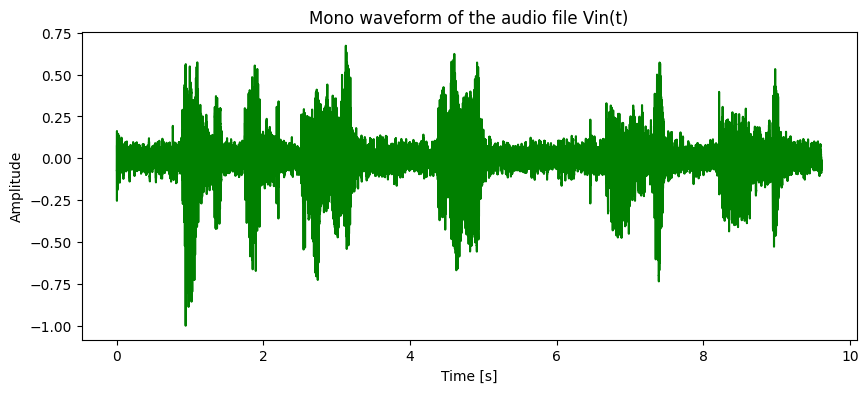

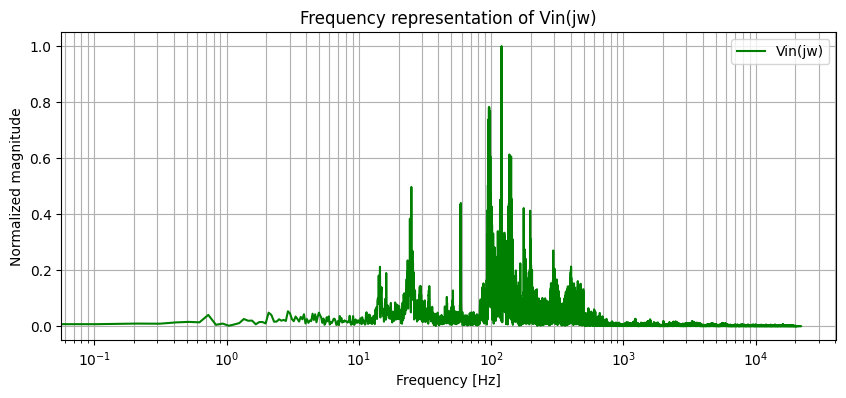

In [3]:
time, data, sample_rate = get_data_from_audio("TC2_in.wav")
data = transform_to_mono(data)
data = normalize_audio(data)
print("Signal duration: %.2f s" % time[-1] )

get_time_graph(time, data).show()


freq_vin, mag_vin = fourier_transform(data, sample_rate)

get_log_graph(
    freq_vin,
    mag_vin,
    'Vin(jw)',
    'Frequency representation of Vin(jw)'
)

plt.show()

### Simule a resposta do alto-falante e apresente os gráficos para i, x, x¨.


In [4]:
def speaker_model(t, state, time, Vin):

    i, x, v = state

    voltage = np.interp(t, time, Vin)

    di_dt = (voltage - R*i - Bl*v) / L
    dx_dt = v
    dv_dt = (Bl*i - b*v - k*x) / m

    return [di_dt, dx_dt, dv_dt]


def plot_speaker_results(time, current, position, acceleration):

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # Current
    axes[0].plot(time, current)
    axes[0].set_ylabel("Current [A]")
    axes[0].set_title("Speaker response")
    axes[0].grid()

    # Displacement
    axes[1].plot(time, position)
    axes[1].set_ylabel("Displacement [m]")
    axes[1].grid()

    # Acceleration
    axes[2].plot(time, acceleration)
    axes[2].set_xlabel("Time [s]")
    axes[2].set_ylabel(r"Acceleration [m/s$^2$]")
    axes[2].grid()

    plt.tight_layout()
    plt.show()

In [ ]:
m = 14.35e-3 #kg
b = 0.786 #kg/s
k = 1852 #N/m
Bl= 4.95 #N/A
L= 266e-6 #H
R= 3.3 #Ohms

state0 = [0, 0, 0]
solution = solve_ivp(
    speaker_model,
    (time[0], time[-1]),
    [0, 0, 0],
    t_eval=time,
    args=(time, data)
)

# Estados
current = solution.y[0]
position = solution.y[1]
velocity = solution.y[2]

# Aceleração
acceleration = (
    Bl*current - b*velocity - k*position
) / m

TypeError: speaker_model() missing 2 required positional arguments: 'time' and 'Vin'

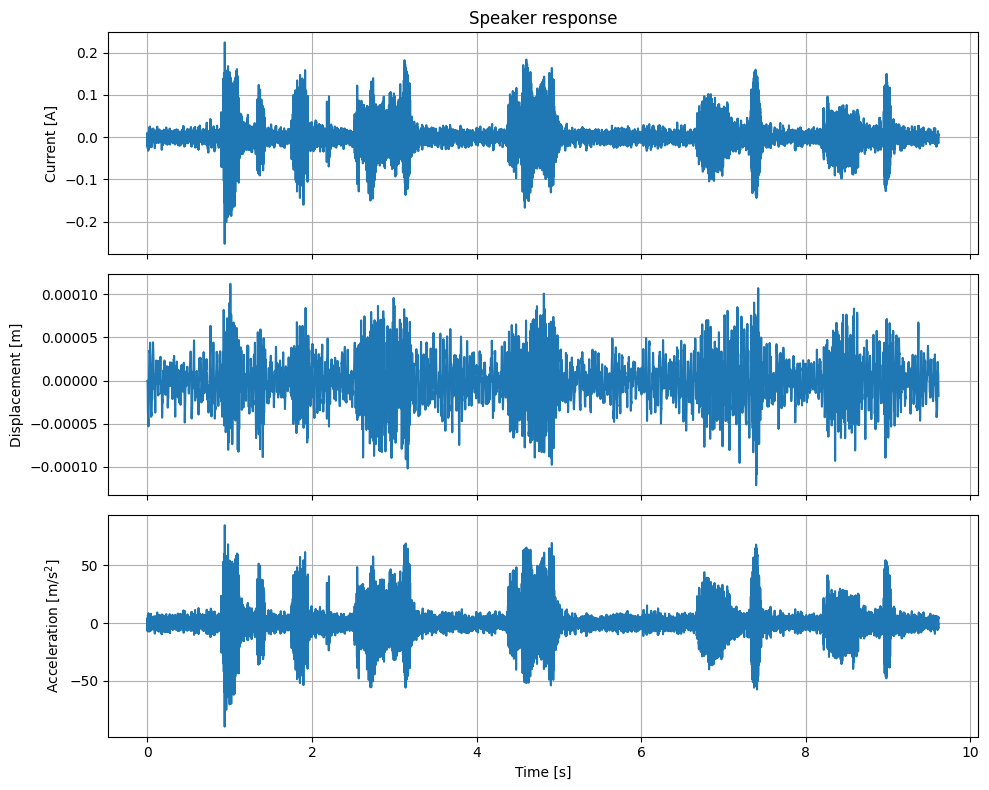

In [ ]:
plot_speaker_results(
    time,
    current,
    position,
    acceleration
)

### Apresente x¨(t) e x¨(jω). Compare com Vin.

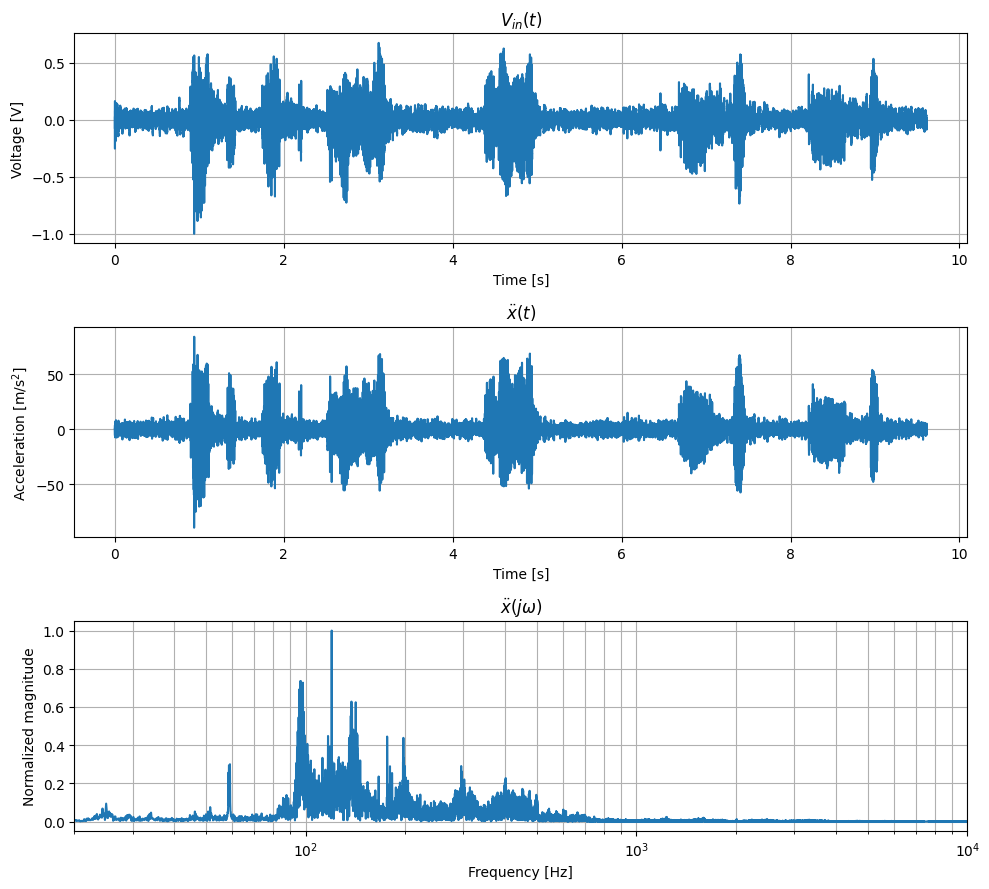

In [ ]:
def plot_acceleration_comparison(
    time: np.ndarray,
    Vin: np.ndarray,
    acceleration: np.ndarray,
    sample_rate: float
):
    
    # x''(jw) = FFT(x''(t))
    freq_acc, mag_acc = fourier_transform(
        acceleration,
        sample_rate
    )

    # Plot
    fig, axes = plt.subplots(3, 1, figsize=(10, 9))

    # Vin(t)
    axes[0].plot(time, Vin)
    axes[0].set_title(r'$V_{in}(t)$')
    axes[0].set_xlabel('Time [s]')
    axes[0].set_ylabel('Voltage [V]')
    axes[0].grid()

    # x''(t)
    axes[1].plot(time, acceleration)
    axes[1].set_title(r'$\ddot{x}(t)$')
    axes[1].set_xlabel('Time [s]')
    axes[1].set_ylabel(r'Acceleration [m/s$^2$]')
    axes[1].grid()

    # x''(jw)
    axes[2].semilogx(freq_acc, mag_acc)
    axes[2].set_title(r'$\ddot{x}(j\omega)$')
    axes[2].set_xlabel('Frequency [Hz]')
    axes[2].set_ylabel('Normalized magnitude')
    axes[2].set_xlim(20, 1e4)
    axes[2].grid(True, which='both')

    plt.tight_layout()

plot_acceleration_comparison(time=time,Vin=data,acceleration=acceleration, sample_rate=sample_rate)

### Salve x¨(t) no arquivo TC02-out1.wav.


In [ ]:

save_audio("TC02-out1.wav", acceleration, int(sample_rate))

## Atividade 02 - Criando um modelo não linear para o alto-falante

Neste trabalho usaremos o mesmo modelo do alto-falante apresentado na aula anterior. Entretanto, iremos assumir que o fator de força Bl diminue à medida que o alto-falante se afasta da sua posição de repouso x = 0. Para |x| ≤ x1 o fator de força é constante e igual ao modelo linear. Para |x| ≥ x2 os valores são nulos. No intervalo x1 ≤ |x| ≤ x2 o parâmetro assume um decaimento polinomial. Defina x1 e x2 como 75% e 150% da excursâo máxima da posição do cone no modelo linear. Utilize um modelo polinomial de ordem 2.

#### Definição do modelo não linear para Bl

In [ ]:
xmax = np.max(np.abs(position))

x1 = 0.75 * xmax
x2 = 1.50 * xmax

def nonlinear_Bl(x, Bl0, x1, x2):

    abs_x = np.abs(x)

    if abs_x <= x1:
        return Bl0

    elif abs_x >= x2:
        return 0.0

    else:
        return Bl0 * (
            1 - (abs_x - x1) / (x2 - x1)
        )**2

#### Definição do modelo de alto falante não linear (nonlinear speaker model)

In [ ]:
def nonlinear_speaker_model(t, state, time, Vin):

    i, x, v = state

    voltage = np.interp(t, time, Vin)

    Bl_x = nonlinear_Bl(x, Bl, x1, x2)

    di_dt = (voltage - R*i - Bl_x*v) / L
    dx_dt = v
    dv_dt = (Bl_x*i - b*v - k*x) / m

    return [di_dt, dx_dt, dv_dt]

## Atividade 03 - Implemente e avalie o modelo não linear para o alto-falante


### Simule a resposta do alto-falante e apresente os gráficos para i, x, x¨.


Simulação:

In [ ]:
solution_nonlinear = solve_ivp(
    nonlinear_speaker_model,
    (time[0], time[-1]),
    [0, 0, 0],
    t_eval=time,
    Vin=data
)

current_nl = solution_nonlinear.y[0]
position_nl = solution_nonlinear.y[1]
velocity_nl = solution_nonlinear.y[2]

Bl_nl = np.array([
    nonlinear_Bl(x, Bl, x1, x2)
    for x in position_nl
])

acceleration_nl = (
    Bl_nl * current_nl
    - b * velocity_nl
    - k * position_nl
) / m

Gráficos para i, x, x¨:

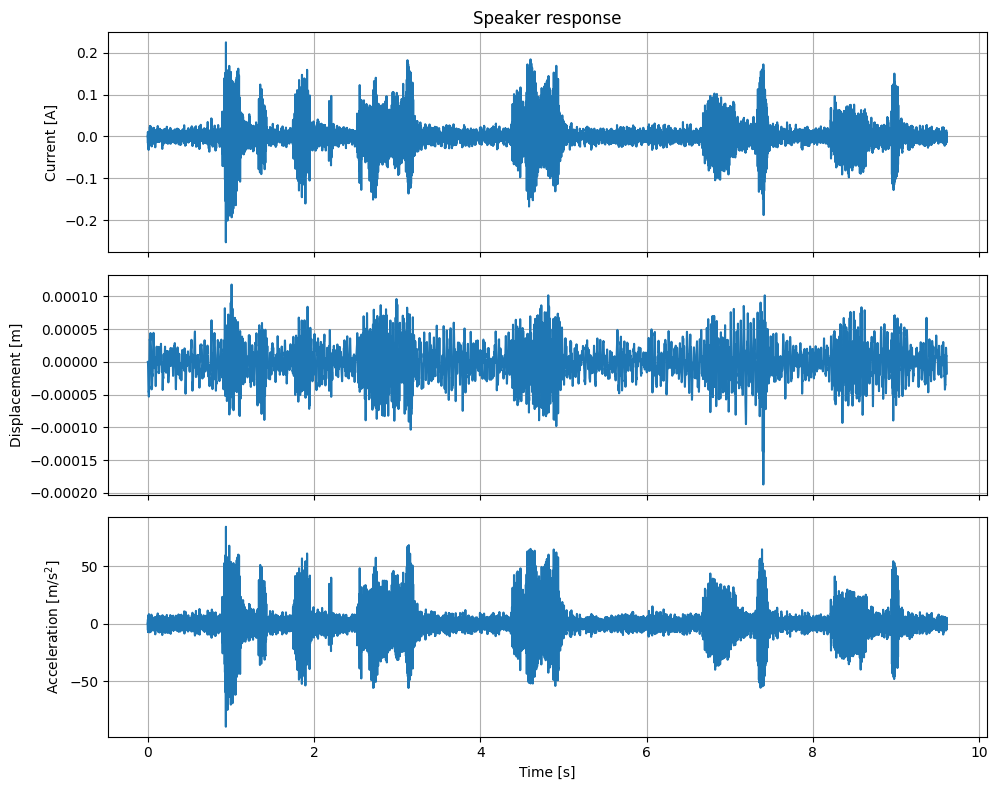

In [ ]:
plot_speaker_results(
    time,
    current_nl,
    position_nl,
    acceleration_nl
)

### Apresente x¨(t) e x¨(jω). Compare com Vin.

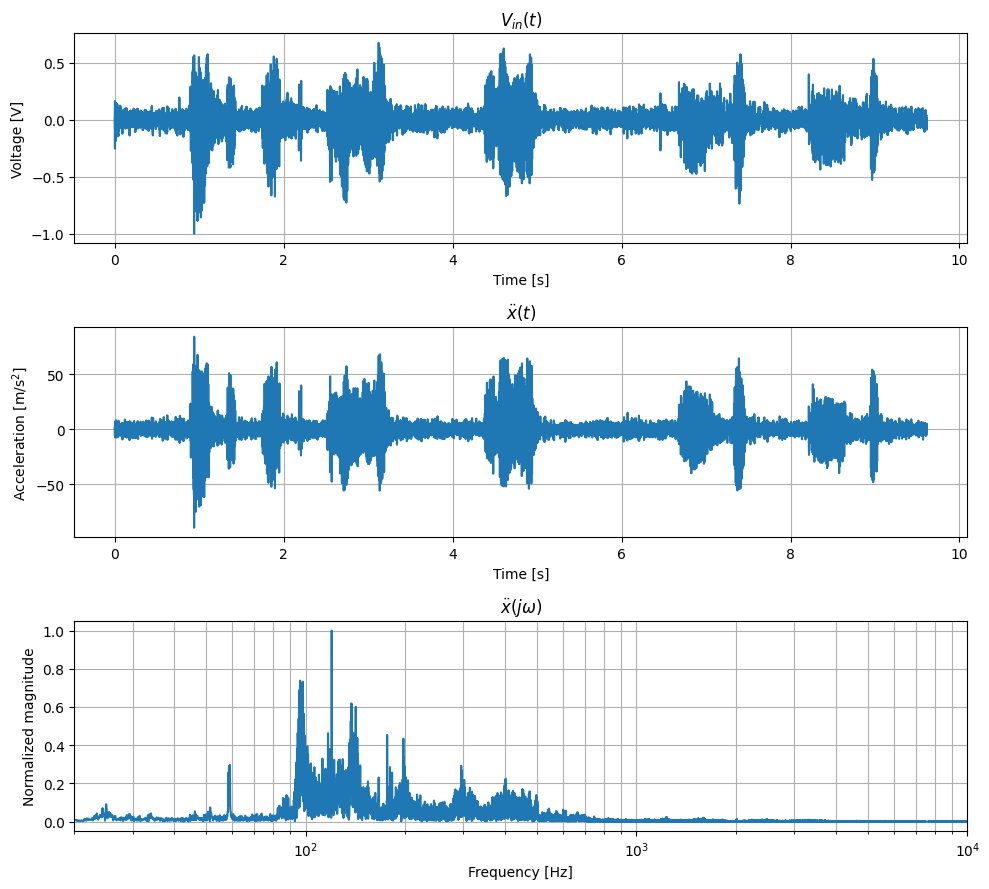

In [ ]:
plot_acceleration_comparison(time,data,acceleration_nl,sample_rate)

### Salve x¨(t) no arquivo TC02-out2-nl.wav


In [ ]:

save_audio("TC02-out2-nl.wav", acceleration_nl, int(sample_rate))

## Atividade 04 - resposta a um sinal senoidal

In [ ]:
f_sine = 500       # Hz
amplitude = 2      # V

Vin_sine = amplitude * np.sin(2 * np.pi * f_sine * time)

In [ ]:
solution_linear = solve_ivp(
    speaker_model,
    (time[0], time[-1]),
    [0, 0, 0],
    t_eval=time,
    args=(time, Vin_sine)
)

solution_nonlinear = solve_ivp(
    nonlinear_speaker_model,
    (time[0], time[-1]),
    [0, 0, 0],
    t_eval=time,
    args=(time, Vin_sine)
)

In [ ]:
# Linear
i_linear = solution_linear.y[0]
x_linear = solution_linear.y[1]
v_linear = solution_linear.y[2]

acceleration_linear = (
    Bl*i_linear
    - b*v_linear
    - k*x_linear
) / m


# Nonlinear
i_nl = solution_nonlinear.y[0]
x_nl = solution_nonlinear.y[1]
v_nl = solution_nonlinear.y[2]

Bl_nl = np.array([
    nonlinear_Bl(x, Bl, x1, x2)
    for x in x_nl
])

acceleration_nl = (
    Bl_nl*i_nl
    - b*v_nl
    - k*x_nl
) / m

C:\Users\talva\AppData\Local\Temp\ipykernel_12304\3885051299.py:49: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


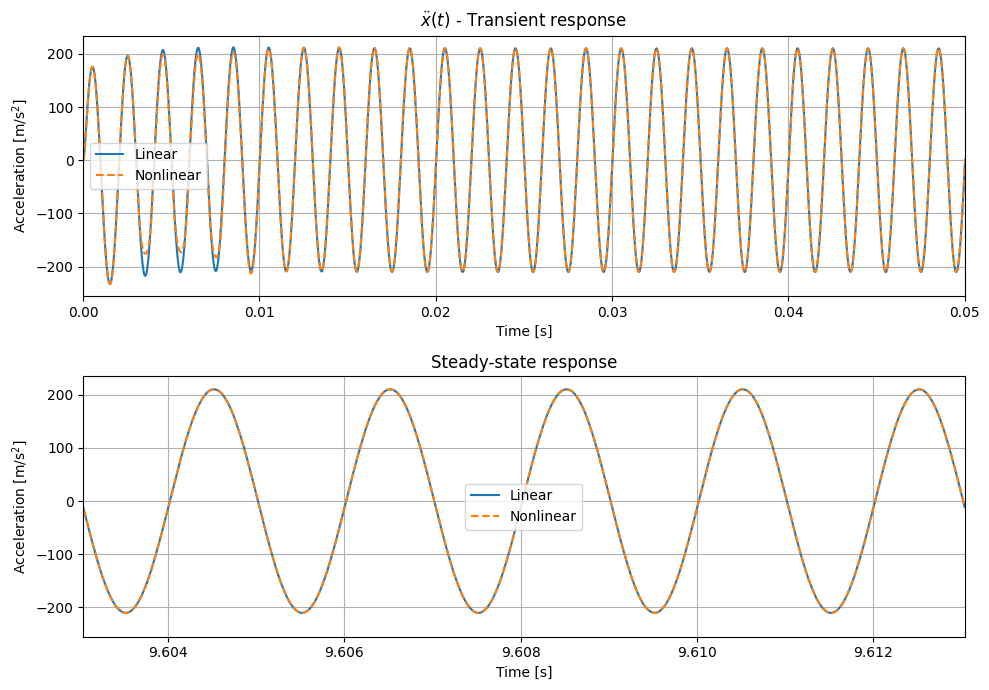

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# Resposta transitória
axes[0].plot(
    time,
    acceleration_linear,
    label='Linear'
)

axes[0].plot(
    time,
    acceleration_nl,
    '--',
    label='Nonlinear'
)

axes[0].set_xlim(0, 0.05)
axes[0].set_title(r'$\ddot{x}(t)$ - Transient response')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel(r'Acceleration [m/s$^2$]')
axes[0].grid()
axes[0].legend()


# Resposta permanente
axes[1].plot(
    time,
    acceleration_linear,
    label='Linear'
)

axes[1].plot(
    time,
    acceleration_nl,
    '--',
    label='Nonlinear'
)

# Últimos 5 períodos
period = 1 / f_sine
axes[1].set_xlim(time[-1] - 5*period, time[-1])

axes[1].set_title('Steady-state response')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel(r'Acceleration [m/s$^2$]')
axes[1].grid()
axes[1].legend()

plt.tight_layout()